# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leiandrei/flyrank-ml-internship-starter/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*
- **Action Strategy:** This playbook serves as an observational or directional analysis for a decision-making for the stakeholders, and to identify pages or contents that currently underperforms their structural potential

##### **Reason Codes:**
- `REWRITE_META_TOP_RANK`: Triggered when `avg_position` is <= 5> but the CTR deficit is high. **Action:** The page is visible but ignored. Rewrite the Title Tag and Meta Description to better match user intent.
- `INVESITGATE_SERP_FEATURES`: Triggered when `ctr_deficit` is massive but rank is decent (Positions 5-10). **Action:** Manually review the SERP. The organic link may be pushed below the fold by AI Overviews, Ads, or Local Packs.
- `DEPRIOTITIZE_GHOST_TOWN`: The reason code for when the page ranks lower or deeper (Position 30+) with low volume. **Action:** Do not allocate editorial resources here; the model's high prediction is a statistical hallucination.

In [14]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import os, sys, subprocess
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

df = pd.read_csv("../outputs/baseline_action_score.csv")
df.head()

,content_id,search_volume,avg_position,ctr,main_intent_commercial,main_intent_informational,main_intent_navigational,main_intent_transactional,content_type_comparison article,content_type_feedly article,content_type_keyword article,predicted_ctr,ctr_deficit
0,content_54f5b78e42f6,NaN,25.0,0.0,0,0,0,0,0,1,0,32.770817,32.770817
1,content_9952eb329b9c,NaN,25.0,0.0,0,0,0,0,0,1,0,32.770817,32.770817
2,content_d45265ca5145,NaN,0.7,0.0,0,0,0,0,0,1,0,27.387153,27.387153
3,content_8a7cfae5dfd8,0.0,98.0,0.0,0,1,0,0,0,0,1,23.885714,23.885714
4,content_e957954137ee,NaN,30.0,0.0,0,0,0,0,0,1,0,20.601587,20.601587


In [15]:
mask = [
    (df['avg_position'] <= 5) & (df['ctr_deficit'] > 10),
    (df['avg_position'] > 5) & (df['avg_position'] <= 15) & (df['ctr_deficit'] > 5),
    (df['avg_position'] > 30)
]

reason_codes = ['REWRITE_META_TOP_RANK', 'INVESTIGATE_SERP_FEATURES', 'DEPRIORITIZE_GHOST_TOWN']

df['recommended_action'] = np.select(mask, reason_codes, default='MONITOR_PERFORMANCE')

display_queue = df[['content_id', 'avg_position', 'ctr', 'predicted_ctr', 'ctr_deficit', 'recommended_action']]
display_queue.head(10)

,content_id,avg_position,ctr,predicted_ctr,ctr_deficit,recommended_action
0,content_54f5b78e42f6,25.0,0.00,32.770817,32.770817,MONITOR_PERFORMANCE
1,content_9952eb329b9c,25.0,0.00,32.770817,32.770817,MONITOR_PERFORMANCE
2,content_d45265ca5145,0.7,0.00,27.387153,27.387153,REWRITE_META_TOP_RANK
3,content_8a7cfae5dfd8,98.0,0.00,23.885714,23.885714,DEPRIORITIZE_GHOST_TOWN
4,content_e957954137ee,30.0,0.00,20.601587,20.601587,MONITOR_PERFORMANCE
5,content_df644d79fad9,30.0,0.00,20.601587,20.601587,MONITOR_PERFORMANCE
6,content_651845c6c973,30.0,0.00,20.601587,20.601587,MONITOR_PERFORMANCE
7,content_48724397d104,2.5,5.26,25.650266,20.390266,REWRITE_META_TOP_RANK
8,content_8adc35ac7ead,1.0,0.00,19.123825,19.123825,REWRITE_META_TOP_RANK
9,content_f989e5fd85ed,1.0,0.00,19.123825,19.123825,REWRITE_META_TOP_RANK


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Intended Use:** This playbook is designed as a directional decision-support triage tool for Content Strategists and SEO Managers. It is meant to quickly surface underperforming pages within an existing client's portfolio to prioritize weekly editorial sprints.

**Limits:** As measured during grouped validation, this model cannot accurately forecast CTR for brand-new, unseen client domains. It relies on macro-level signals (search_volume, avg_position) and lacks qualitative text data (brand authority, persuasive copywriting). Therefore, the `ctr_deficit` is a relative triage metric, not an absolute guarantee of future traffic.

In [16]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

##### **Human Review Requirements:**

- **Visual SERP Verification:** A human must manually search the target keyword to confirm the visual layout. A high deficit might be caused by Google placing an AI Overview directly above our link, rendering meta-tag optimization useless.
- **Cost/Value Thinking:** Only execute a refresh if the `search_volume` and cpc (value) justify the editorial hours.

##### **The No-Go List (DO NOT AUTOMATE):**

- **No Automated Rewrites:** Do not connect this output directly to a Generative AI pipeline to automatically rewrite and publish Title Tags. Branded queries or compliance-heavy pages could be dangerously altered.
- **No Automated Deletions:** Never automate the deletion or redirection of "Ghost Town" pages without verifying their historical traffic or backlink profiles in Google Search Console.

In [17]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

##### **Monitoring & Retrain Triggers:**

- **Major Algorithm Updates:** If Google rolls out a Core Update or a major expansion to AI Overviews, the structural relationship between avg_position and ctr will shift. The model must be retrained on post-update data.

- **Global CTR Decay:** If the model begins flagging >50% of the entire portfolio as `REWRITE_META_TOP_RANK`, it indicates the baseline CTR expectations are stale and too high.

- **Data Drift:** Retrain the model quarterly to capture new standard baseline behaviors for content_type and main_intent.

In [18]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

C:\Users\LEI\AppData\Local\Temp\ipykernel_4176\729594366.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='recommended_action', palette='viridis', ax=ax, edgecolor='black', alpha=0.85)


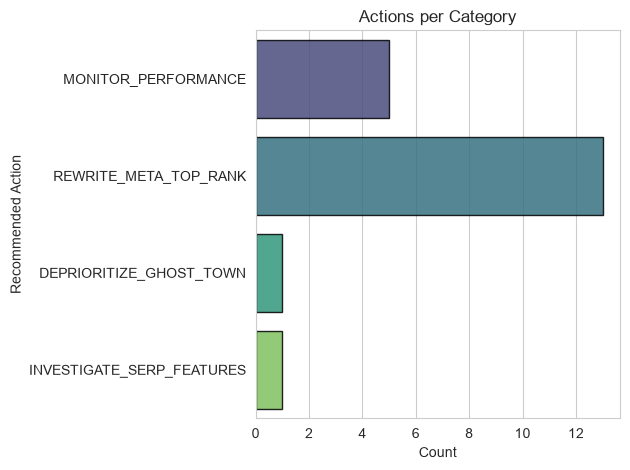

In [26]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
df.to_csv('../outputs/final_content_action_playbook.csv', index=False)

sns.set_style('whitegrid')

fig, ax = plt.subplots()

sns.countplot(data=df, y='recommended_action', palette='viridis', ax=ax, edgecolor='black', alpha=0.85)
ax.set_title('Actions per Category')
ax.set_xlabel('Count')
ax.set_ylabel('Recommended Action')

plt.tight_layout()

plt.savefig('../outputs/action_distribution_chart.svg', dpi=300)

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.